<a href="https://colab.research.google.com/github/MuhammadAqsandy/midterm-ML12/blob/main/regresi_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎵 Song Release Year Prediction — End-to-End Regression Pipeline
### Hands-On End-to-End Models: Machine Learning and Deep Learning
**Individual Task — Regresi**

---
| | |
|---|---|
| **Models** | XGBoost Regressor, LightGBM Regressor, Ridge Regression |
| **Tuning** | Optuna (Hyperparameter Optimization) |
| **Tracking** | MLflow |
| **Interpretasi** | LIME (Local Interpretable Model-agnostic Explanations) |
| **Metrics** | MSE, RMSE, MAE, R² |

---
> ⚠️ **Pastikan Runtime → Change runtime type → T4 GPU sebelum mulai!**

## ⚙️ STEP 0 — Install Libraries

In [ ]:
!pip install -q numpy pandas matplotlib seaborn scikit-learn xgboost lightgbm optuna mlflow lime
print('✅ Semua library berhasil diinstall!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.4 MB/s eta 0:00:00
   ━━

## 📁 STEP 1 — Upload Dataset

In [ ]:
from google.colab import files

print('Upload midterm-regresi-dataset.csv ...')
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print(f'✅ File berhasil diupload: {filename}')

Upload midterm-regresi-dataset.csv ...


Saving regresi_colab.ipynb to regresi_colab (1).ipynb
✅ File berhasil diupload: regresi_colab (1).ipynb


## 📦 STEP 2 — Import Libraries & Konfigurasi

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

import xgboost as xgb
import lightgbm as lgb
import optuna
import mlflow
import mlflow.xgboost
import mlflow.lightgbm
import mlflow.sklearn
import lime
import lime.lime_tabular

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Konfigurasi Global
RANDOM_STATE = 42
TEST_SIZE    = 0.2
N_TRIALS     = 30
CV_FOLDS     = 5
MLFLOW_EXP   = 'SongYear_Regression_Experiment'

print('✅ Import selesai!')

✅ Import selesai!


## 📊 STEP 3 — Load & Eksplorasi Data

In [ ]:
filename = 'midterm-regresi-dataset.csv' # Assuming this is the correct CSV dataset filename

In [ ]:
# Load data — kolom pertama adalah target (tahun rilis)
df = pd.read_csv(filename, header=None)

# Beri nama kolom
df.columns = ['year'] + [f'feature_{i}' for i in range(1, df.shape[1])]
TARGET_COL  = 'year'

print(f'Shape dataset  : {df.shape[0]:,} baris × {df.shape[1]} kolom')
print(f'Target (year)  : min={df[TARGET_COL].min():.0f}, max={df[TARGET_COL].max():.0f}, '
      f'mean={df[TARGET_COL].mean():.1f}')
print(f'Missing values : {df.isnull().sum().sum()}')
df.head()

Shape dataset  : 515,345 baris × 91 kolom
Target (year)  : min=1922, max=2011, mean=1998.4
Missing values : 0


,year,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_81,feature_82,feature_83,feature_84,feature_85,feature_86,feature_87,feature_88,feature_89,feature_90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903


## 📈 STEP 4 — Exploratory Data Analysis (EDA)

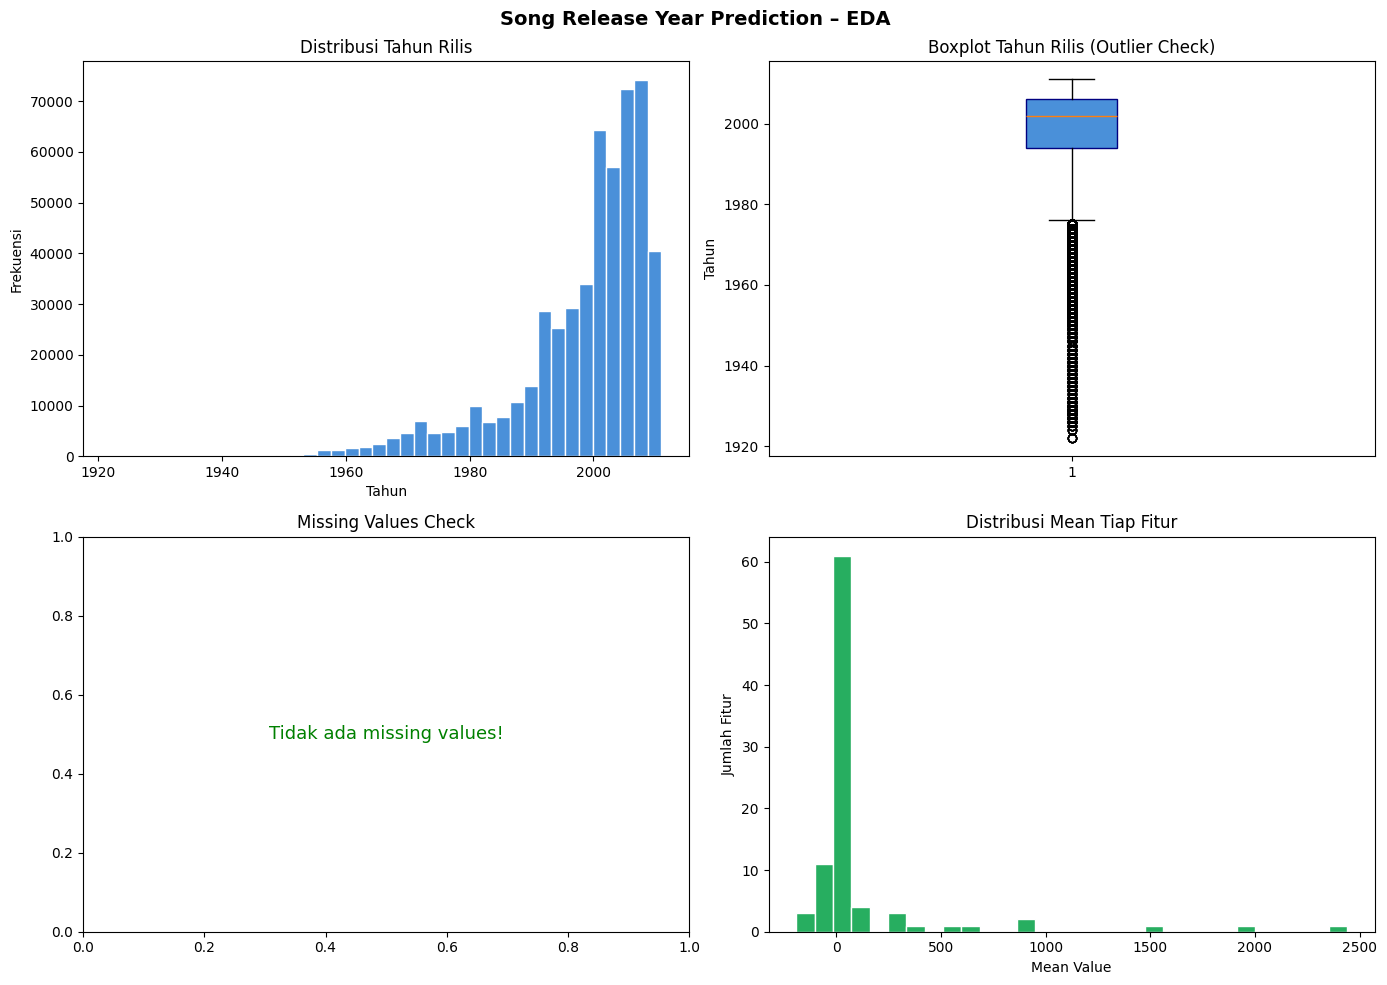

✅ EDA selesai!


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Song Release Year Prediction – EDA', fontsize=14, fontweight='bold')

# 1. Distribusi target (tahun rilis)
axes[0][0].hist(df[TARGET_COL], bins=40, color='#4a90d9', edgecolor='white')
axes[0][0].set_title('Distribusi Tahun Rilis')
axes[0][0].set_xlabel('Tahun')
axes[0][0].set_ylabel('Frekuensi')

# 2. Boxplot outlier target
axes[0][1].boxplot(df[TARGET_COL], vert=True, patch_artist=True,
                   boxprops=dict(facecolor='#4a90d9', color='navy'))
axes[0][1].set_title('Boxplot Tahun Rilis (Outlier Check)')
axes[0][1].set_ylabel('Tahun')

# 3. Distribusi missing values per fitur
missing = df.isnull().mean().sort_values(ascending=False)
missing_nonzero = missing[missing > 0]
if len(missing_nonzero) > 0:
    axes[1][0].barh(missing_nonzero.index[:20], missing_nonzero.values[:20], color='#e67e22')
    axes[1][0].set_title('Missing Values per Fitur (top 20)')
else:
    axes[1][0].text(0.5, 0.5, 'Tidak ada missing values!', ha='center', va='center',
                    transform=axes[1][0].transAxes, fontsize=13, color='green')
    axes[1][0].set_title('Missing Values Check')

# 4. Statistik deskriptif fitur (mean dari tiap fitur)
feat_means = df.drop(columns=[TARGET_COL]).mean().values
axes[1][1].hist(feat_means, bins=30, color='#27ae60', edgecolor='white')
axes[1][1].set_title('Distribusi Mean Tiap Fitur')
axes[1][1].set_xlabel('Mean Value')
axes[1][1].set_ylabel('Jumlah Fitur')

plt.tight_layout()
plt.savefig('eda_regression.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA selesai!')

## 🔧 STEP 5 — Preprocessing
> Handle outlier → Impute → Train/Test Split → Feature Scaling

In [ ]:
df_proc = df.copy()

# ── Handle outlier target dengan IQR clipping
Q1 = df_proc[TARGET_COL].quantile(0.01)
Q3 = df_proc[TARGET_COL].quantile(0.99)
before = len(df_proc)
df_proc = df_proc[(df_proc[TARGET_COL] >= Q1) & (df_proc[TARGET_COL] <= Q3)]
print(f'Outlier target dibuang : {before - len(df_proc)} baris')
print(f'Dataset setelah clip   : {len(df_proc):,} baris')

# ── Pisahkan fitur dan target
X = df_proc.drop(columns=[TARGET_COL]).values
y = df_proc[TARGET_COL].values
feature_names = df_proc.drop(columns=[TARGET_COL]).columns.tolist()

# ── Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
print(f'Train : {X_train.shape[0]:,} baris | Test : {X_test.shape[0]:,} baris')

# ── Impute missing values (jika ada)
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_test  = imputer.transform(X_test)

# ── Feature Scaling
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('\n✅ Preprocessing selesai!')

Outlier target dibuang : 4930 baris
Dataset setelah clip   : 510,415 baris
Train : 408,332 baris | Test : 102,083 baris

✅ Preprocessing selesai!


## 🔬 STEP 6 — Optuna Hyperparameter Tuning
### 6a. Ridge Regression (Baseline)

In [ ]:
kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

def ridge_objective(trial):
    alpha = trial.suggest_float('alpha', 1e-3, 1000.0, log=True)
    model = Ridge(alpha=alpha)
    scores = cross_val_score(model, X_train_scaled, y_train,
                             cv=kf, scoring='neg_root_mean_squared_error')
    return scores.mean()  # optuna akan maximize → minimize RMSE

study_ridge = optuna.create_study(direction='maximize', study_name='ridge_regression')
study_ridge.optimize(ridge_objective, n_trials=20, show_progress_bar=True)

ridge_best_params = study_ridge.best_params
print(f'\n✅ Ridge Best CV RMSE : {abs(study_ridge.best_value):.4f}')
print(f'   Best alpha        : {ridge_best_params["alpha"]:.4f}')

  0%|          | 0/20 [00:00<?, ?it/s]


✅ Ridge Best CV RMSE : 8.7715
   Best alpha        : 112.2656


### 6b. XGBoost Regressor

In [ ]:
def xgb_objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 200, 1000),
        'max_depth'        : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'tree_method'      : 'hist',
        'device'           : 'cuda',
        'random_state'     : RANDOM_STATE,
        'n_jobs'           : -1,
    }
    rmses = []
    for tr_idx, val_idx in kf.split(X_train):
        clf = xgb.XGBRegressor(**params)
        clf.fit(X_train[tr_idx], y_train[tr_idx],
                eval_set=[(X_train[val_idx], y_train[val_idx])],
                verbose=False)
        pred  = clf.predict(X_train[val_idx])
        rmses.append(np.sqrt(mean_squared_error(y_train[val_idx], pred)))
    return -np.mean(rmses)  # maximize negative RMSE

study_xgb = optuna.create_study(direction='maximize', study_name='xgboost_reg')
study_xgb.optimize(xgb_objective, n_trials=N_TRIALS, show_progress_bar=True)

xgb_best_params = study_xgb.best_params
print(f'\n✅ XGBoost Best CV RMSE : {abs(study_xgb.best_value):.4f}')
print(f'   Best params         : {xgb_best_params}')

  0%|          | 0/30 [00:00<?, ?it/s]

### 6c. LightGBM Regressor

In [ ]:
def lgb_objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 200, 1000),
        'max_depth'        : trial.suggest_int('max_depth', 3, 12),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 300),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'device'           : 'gpu',
        'random_state'     : RANDOM_STATE,
        'n_jobs'           : -1,
        'verbose'          : -1,
    }
    rmses = []
    for tr_idx, val_idx in kf.split(X_train):
        clf = lgb.LGBMRegressor(**params)
        clf.fit(X_train[tr_idx], y_train[tr_idx],
                eval_set=[(X_train[val_idx], y_train[val_idx])])
        pred  = clf.predict(X_train[val_idx])
        rmses.append(np.sqrt(mean_squared_error(y_train[val_idx], pred)))
    return -np.mean(rmses)

study_lgb = optuna.create_study(direction='maximize', study_name='lightgbm_reg')
study_lgb.optimize(lgb_objective, n_trials=N_TRIALS, show_progress_bar=True)

lgb_best_params = study_lgb.best_params
print(f'\n✅ LightGBM Best CV RMSE : {abs(study_lgb.best_value):.4f}')
print(f'   Best params          : {lgb_best_params}')

## 🏋️ STEP 7 — Train Final Models + MLflow Tracking

In [ ]:
mlflow.set_experiment(MLFLOW_EXP)
results = {}

def evaluate_regression(name, y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f'\n── {name} ─────────────────────────────────────')
    print(f'  MSE  : {mse:.4f}')
    print(f'  RMSE : {rmse:.4f}  ← rata-rata error dalam satuan tahun')
    print(f'  MAE  : {mae:.4f}')
    print(f'  R²   : {r2:.4f}  ← semakin mendekati 1.0 semakin baik')
    return {'mse': mse, 'rmse': rmse, 'mae': mae, 'r2': r2}

# ─── Ridge ──────────────────────────────────────────────────────────────────
with mlflow.start_run(run_name='Ridge_Best'):
    clf_ridge = Ridge(**ridge_best_params)
    clf_ridge.fit(X_train_scaled, y_train)
    y_pred_ridge = clf_ridge.predict(X_test_scaled)
    metrics_ridge = evaluate_regression('Ridge', y_test, y_pred_ridge)
    mlflow.log_params(ridge_best_params)
    mlflow.log_metrics(metrics_ridge)
    mlflow.sklearn.log_model(clf_ridge, 'ridge_model')
    results['Ridge'] = {'model': clf_ridge, 'y_pred': y_pred_ridge,
                        'metrics': metrics_ridge, 'scaled': True}

# ─── XGBoost ────────────────────────────────────────────────────────────────
with mlflow.start_run(run_name='XGBoost_Best'):
    xgb_final = {**xgb_best_params,
                 'tree_method': 'hist', 'device': 'cuda',
                 'random_state': RANDOM_STATE, 'n_jobs': -1}
    clf_xgb = xgb.XGBRegressor(**xgb_final)
    clf_xgb.fit(X_train, y_train, verbose=False)
    y_pred_xgb = clf_xgb.predict(X_test)
    metrics_xgb = evaluate_regression('XGBoost', y_test, y_pred_xgb)
    mlflow.log_params(xgb_final)
    mlflow.log_metrics(metrics_xgb)
    mlflow.xgboost.log_model(clf_xgb, 'xgboost_model')
    results['XGBoost'] = {'model': clf_xgb, 'y_pred': y_pred_xgb,
                          'metrics': metrics_xgb, 'scaled': False}

# ─── LightGBM ───────────────────────────────────────────────────────────────
with mlflow.start_run(run_name='LightGBM_Best'):
    lgb_final = {**lgb_best_params,
                 'device': 'gpu', 'random_state': RANDOM_STATE,
                 'n_jobs': -1, 'verbose': -1}
    clf_lgb = lgb.LGBMRegressor(**lgb_final)
    clf_lgb.fit(X_train, y_train)
    y_pred_lgb = clf_lgb.predict(X_test)
    metrics_lgb = evaluate_regression('LightGBM', y_test, y_pred_lgb)
    mlflow.log_params(lgb_final)
    mlflow.log_metrics(metrics_lgb)
    mlflow.lightgbm.log_model(clf_lgb, 'lightgbm_model')
    results['LightGBM'] = {'model': clf_lgb, 'y_pred': y_pred_lgb,
                           'metrics': metrics_lgb, 'scaled': False}

print('\n✅ Training dan MLflow tracking selesai!')

## 📉 STEP 8 — Visualisasi Hasil

In [ ]:
colors = {'Ridge': '#9b59b6', 'XGBoost': '#e74c3c', 'LightGBM': '#27ae60'}

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Song Release Year Prediction – Model Results', fontsize=14, fontweight='bold')

# ── Row 0: Actual vs Predicted per model
for col_idx, (name, res) in enumerate(results.items()):
    ax = axes[0][col_idx]
    ax.scatter(y_test, res['y_pred'], alpha=0.3, s=8, color=colors[name])
    mn = min(y_test.min(), res['y_pred'].min())
    mx = max(y_test.max(), res['y_pred'].max())
    ax.plot([mn, mx], [mn, mx], 'k--', lw=1.5, label='Perfect Prediction')
    ax.set_title(f"{name}\nR²={res['metrics']['r2']:.4f} | RMSE={res['metrics']['rmse']:.3f}")
    ax.set_xlabel('Actual Year')
    ax.set_ylabel('Predicted Year')
    ax.legend(fontsize=8)

# ── Row 1 col 0: Metric Comparison Bar Chart
ax_bar = axes[1][0]
metric_keys = ['rmse', 'mae', 'r2']
x = np.arange(len(metric_keys))
width = 0.25
for i, (name, res) in enumerate(results.items()):
    vals = [res['metrics'][k] for k in metric_keys]
    ax_bar.bar(x + i * width, vals, width, label=name, color=colors[name])
ax_bar.set_xticks(x + width)
ax_bar.set_xticklabels(['RMSE', 'MAE', 'R²'])
ax_bar.set_title('Metric Comparison')
ax_bar.legend()

# ── Row 1 col 1: Residual Distribution (best model)
best_name = min(results, key=lambda k: results[k]['metrics']['rmse'])
best_res  = results[best_name]
residuals = y_test - best_res['y_pred']
axes[1][1].hist(residuals, bins=40, color=colors[best_name], edgecolor='white')
axes[1][1].axvline(0, color='black', linestyle='--', lw=1.5)
axes[1][1].set_title(f'Residual Distribution\n({best_name} — Best Model)')
axes[1][1].set_xlabel('Residual (Actual − Predicted)')
axes[1][1].set_ylabel('Count')

# ── Row 1 col 2: Feature Importance (best tree model)
tree_models = {k: v for k, v in results.items() if k in ['XGBoost', 'LightGBM']}
best_tree   = min(tree_models, key=lambda k: results[k]['metrics']['rmse'])
imp = results[best_tree]['model'].feature_importances_
top_idx = np.argsort(imp)[-20:]
axes[1][2].barh([feature_names[i] for i in top_idx], imp[top_idx],
                color=colors[best_tree])
axes[1][2].set_title(f'Top-20 Feature Importance\n({best_tree})')
axes[1][2].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('regression_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualisasi disimpan → regression_results.png')

## 🔍 STEP 9 — LIME: Interpretasi Model
> LIME menjelaskan **mengapa** model membuat prediksi tertentu pada satu sampel

In [ ]:
# Gunakan best model untuk LIME
best_model_name = min(results, key=lambda k: results[k]['metrics']['rmse'])
best_model      = results[best_model_name]['model']
use_scaled      = results[best_model_name]['scaled']

X_train_lime = X_train_scaled if use_scaled else X_train
X_test_lime  = X_test_scaled  if use_scaled else X_test

print(f'Menggunakan model terbaik: {best_model_name}')

# Buat LIME explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data  = X_train_lime,
    feature_names  = feature_names,
    mode           = 'regression',
    random_state   = RANDOM_STATE
)

# Jelaskan 3 prediksi sampel dari test set
sample_indices = [0, 1, 2]

for idx in sample_indices:
    instance    = X_test_lime[idx]
    actual      = y_test[idx]
    predicted   = best_model.predict(instance.reshape(1, -1))[0]

    explanation = explainer.explain_instance(
        data_row       = instance,
        predict_fn     = best_model.predict,
        num_features   = 10
    )

    print(f'\n── Sampel #{idx} ──────────────────────────────────')
    print(f'  Actual Year    : {actual:.0f}')
    print(f'  Predicted Year : {predicted:.1f}')
    print(f'  Error          : {abs(actual - predicted):.1f} tahun')
    print(f'  Top features   :')
    for feat, weight in explanation.as_list():
        direction = '▲ positif' if weight > 0 else '▼ negatif'
        print(f'    {feat:<35} → {weight:+.4f}  ({direction})')

    # Plot LIME explanation
    fig = explanation.as_pyplot_figure()
    fig.suptitle(f'LIME — {best_model_name} | Sampel #{idx}\n'
                 f'Actual: {actual:.0f} | Predicted: {predicted:.1f}',
                 fontsize=11)
    plt.tight_layout()
    plt.savefig(f'lime_sample_{idx}.png', dpi=150, bbox_inches='tight')
    plt.show()

print('\n✅ LIME interpretasi selesai!')

## 🏆 STEP 10 — Summary & Interpretasi Hasil

In [ ]:
print('=' * 65)
print('  FINAL SUMMARY — REGRESSION METRICS')
print('=' * 65)
print(f'  {"Model":<12} | {"MSE":>10} | {"RMSE":>8} | {"MAE":>8} | {"R²":>8}')
print('-' * 65)
for name, res in results.items():
    m = res['metrics']
    print(f"  {name:<12} | {m['mse']:>10.4f} | {m['rmse']:>8.4f} | "
          f"{m['mae']:>8.4f} | {m['r2']:>8.4f}")
print('=' * 65)

best = min(results, key=lambda k: results[k]['metrics']['rmse'])
bm   = results[best]['metrics']
print(f'\n  ✅ Best model : {best}')
print(f'     RMSE      : {bm["rmse"]:.4f} tahun  ← rata-rata error prediksi')
print(f'     R²        : {bm["r2"]:.4f}  ← model menjelaskan {bm["r2"]*100:.1f}% variasi data')
print()
print('  📝 Interpretasi:')
print(f'     - Model {best} memberikan performa terbaik dengan RMSE {bm["rmse"]:.2f}')
print(f'       artinya rata-rata prediksi meleset sekitar {bm["rmse"]:.1f} tahun')
print(f'     - R² = {bm["r2"]:.4f} menunjukkan model mampu menjelaskan')
print(f'       {bm["r2"]*100:.1f}% variasi tahun rilis lagu dari fitur audio')
print(f'     - LIME menunjukkan fitur audio tertentu memiliki pengaruh')
print(f'       dominan dalam menentukan era/tahun rilis sebuah lagu')
print('=' * 65)

## 📊 STEP 11 — MLflow UI di Colab

In [ ]:
!pip install -q pyngrok
from pyngrok import ngrok
import subprocess, time

subprocess.Popen(['mlflow', 'ui', '--port', '5000'])
time.sleep(3)

public_url = ngrok.connect(5000)
print(f'\n✅ MLflow UI tersedia di: {public_url}')
print('Klik link di atas untuk membuka dashboard MLflow!')